In [6]:
import sys
import os

print("Python Executable:", sys.executable)
print("Python Version:", sys.version)
print("Current Working Directory:", os.getcwd())

Python Executable: C:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe
Python Version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Current Working Directory: C:\Users\HP\LLM`S\exp1


In [7]:
# Install required packages (safe to run multiple times)
%pip install nltk numpy pandas matplotlib

# Import libraries
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("✅ All libraries imported successfully!")

Note: you may need to restart the kernel to use updated packages.
✅ All libraries imported successfully!



[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Download NLTK tokenizer resources (run only once)
nltk.download('punkt')
nltk.download('punkt_tab')

print("✅ NLTK tokenizer data downloaded successfully!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


✅ NLTK tokenizer data downloaded successfully!


In [9]:
# Read the corpus file

with open("corpus.txt", "r", encoding="utf-8") as file:
    corpus = file.read()

print("✅ Corpus Loaded Successfully!\n")
print(corpus)

✅ Corpus Loaded Successfully!

I love artificial intelligence.
Artificial intelligence is changing the world.
I love machine learning.
Machine learning is a part of artificial intelligence.
Language models are very powerful.
Large language models generate text.
Natural language processing is interesting.
I enjoy learning about AI.
AI is transforming technology.
Deep learning improves language models.
Artificial intelligence helps solve real-world problems.
Students learn machine learning using Python.
Large language models understand natural language.
AI applications are growing rapidly.
Language models predict the next word in a sentence.


In [10]:
from nltk.tokenize import word_tokenize, sent_tokenize

# Convert text to lowercase
corpus = corpus.lower()

# Sentence Tokenization
sentences = sent_tokenize(corpus)

# Word Tokenization
tokens = word_tokenize(corpus)

print("Total Sentences:", len(sentences))
print("Total Tokens:", len(tokens))

print("\nFirst 5 Sentences:")
for sentence in sentences[:5]:
    print(sentence)

print("\nFirst 30 Tokens:")
print(tokens[:30])

Total Sentences: 15
Total Tokens: 98

First 5 Sentences:
i love artificial intelligence.
artificial intelligence is changing the world.
i love machine learning.
machine learning is a part of artificial intelligence.
language models are very powerful.

First 30 Tokens:
['i', 'love', 'artificial', 'intelligence', '.', 'artificial', 'intelligence', 'is', 'changing', 'the', 'world', '.', 'i', 'love', 'machine', 'learning', '.', 'machine', 'learning', 'is', 'a', 'part', 'of', 'artificial', 'intelligence', '.', 'language', 'models', 'are', 'very']


In [11]:
from collections import Counter

# Count frequency of each token
unigram_counts = Counter(tokens)

print("Total Unique Tokens:", len(unigram_counts))

print("\nTop 20 Most Frequent Tokens:\n")

for word, count in unigram_counts.most_common(20):
    print(f"{word:15} -> {count}")
    

Total Unique Tokens: 49

Top 20 Most Frequent Tokens:

.               -> 15
language        -> 7
learning        -> 5
models          -> 5
artificial      -> 4
intelligence    -> 4
is              -> 4
i               -> 3
machine         -> 3
ai              -> 3
love            -> 2
the             -> 2
a               -> 2
are             -> 2
large           -> 2
natural         -> 2
changing        -> 1
world           -> 1
part            -> 1
of              -> 1


In [12]:
from nltk.util import ngrams

# Generate bigrams
bigrams = list(ngrams(tokens, 2))

# Count frequency of bigrams
bigram_counts = Counter(bigrams)

print("Total Unique Bigrams:", len(bigram_counts))

print("\nTop 20 Most Frequent Bigrams:\n")

for bg, count in bigram_counts.most_common(20):
    print(f"{bg} -> {count}")

Total Unique Bigrams: 79

Top 20 Most Frequent Bigrams:

('language', 'models') -> 5
('artificial', 'intelligence') -> 4
('machine', 'learning') -> 3
('i', 'love') -> 2
('intelligence', '.') -> 2
('.', 'artificial') -> 2
('.', 'i') -> 2
('.', 'language') -> 2
('.', 'large') -> 2
('large', 'language') -> 2
('natural', 'language') -> 2
('.', 'ai') -> 2
('love', 'artificial') -> 1
('intelligence', 'is') -> 1
('is', 'changing') -> 1
('changing', 'the') -> 1
('the', 'world') -> 1
('world', '.') -> 1
('love', 'machine') -> 1
('learning', '.') -> 1


In [13]:
# Generate trigrams
trigrams = list(ngrams(tokens, 3))

# Count frequency of trigrams
trigram_counts = Counter(trigrams)

print("Total Unique Trigrams:", len(trigram_counts))

print("\nTop 20 Most Frequent Trigrams:\n")

for tg, count in trigram_counts.most_common(20):
    print(f"{tg} -> {count}")
    

Total Unique Trigrams: 91

Top 20 Most Frequent Trigrams:

('artificial', 'intelligence', '.') -> 2
('.', 'artificial', 'intelligence') -> 2
('.', 'language', 'models') -> 2
('.', 'large', 'language') -> 2
('large', 'language', 'models') -> 2
('i', 'love', 'artificial') -> 1
('love', 'artificial', 'intelligence') -> 1
('intelligence', '.', 'artificial') -> 1
('artificial', 'intelligence', 'is') -> 1
('intelligence', 'is', 'changing') -> 1
('is', 'changing', 'the') -> 1
('changing', 'the', 'world') -> 1
('the', 'world', '.') -> 1
('world', '.', 'i') -> 1
('.', 'i', 'love') -> 1
('i', 'love', 'machine') -> 1
('love', 'machine', 'learning') -> 1
('machine', 'learning', '.') -> 1
('learning', '.', 'machine') -> 1
('.', 'machine', 'learning') -> 1


In [14]:
# Function to calculate Bigram MLE Probability

def bigram_probability(word1, word2):
    bigram = (word1, word2)

    if unigram_counts[word1] == 0:
        return 0

    return bigram_counts[bigram] / unigram_counts[word1]


# Test some probabilities

pairs = [
    ("artificial", "intelligence"),
    ("machine", "learning"),
    ("language", "models"),
    ("i", "love"),
    ("love", "python")
]

print("Bigram MLE Probabilities\n")

for w1, w2 in pairs:
    prob = bigram_probability(w1, w2)
    print(f"P({w2} | {w1}) = {prob:.4f}")

Bigram MLE Probabilities

P(intelligence | artificial) = 1.0000
P(learning | machine) = 1.0000
P(models | language) = 0.7143
P(love | i) = 0.6667
P(python | love) = 0.0000


In [15]:
# Vocabulary size
V = len(unigram_counts)

# Laplace (Add-One) Smoothing Function
def laplace_probability(word1, word2):
    bigram = (word1, word2)

    numerator = bigram_counts[bigram] + 1
    denominator = unigram_counts[word1] + V

    return numerator / denominator


# Test the same word pairs
pairs = [
    ("artificial", "intelligence"),
    ("machine", "learning"),
    ("language", "models"),
    ("i", "love"),
    ("love", "python")
]

print("Laplace Smoothed Probabilities\n")

for w1, w2 in pairs:
    prob = laplace_probability(w1, w2)
    print(f"P({w2} | {w1}) = {prob:.4f}")

Laplace Smoothed Probabilities

P(intelligence | artificial) = 0.0943
P(learning | machine) = 0.0769
P(models | language) = 0.1071
P(love | i) = 0.0577
P(python | love) = 0.0196


In [16]:
# Add-k Smoothing Function

k = 0.5

def add_k_probability(word1, word2, k=0.5):
    bigram = (word1, word2)

    numerator = bigram_counts[bigram] + k
    denominator = unigram_counts[word1] + (k * V)

    return numerator / denominator


pairs = [
    ("artificial", "intelligence"),
    ("machine", "learning"),
    ("language", "models"),
    ("i", "love"),
    ("love", "python")
]

print("Add-k Smoothed Probabilities (k = 0.5)\n")

for w1, w2 in pairs:
    prob = add_k_probability(w1, w2)
    print(f"P({w2} | {w1}) = {prob:.4f}")

Add-k Smoothed Probabilities (k = 0.5)

P(intelligence | artificial) = 0.1579
P(learning | machine) = 0.1273
P(models | language) = 0.1746
P(love | i) = 0.0909
P(python | love) = 0.0189


In [17]:
# Interpolation (Bigram + Unigram)

lambda1 = 0.7

def interpolation_probability(word1, word2):
    bigram_prob = bigram_probability(word1, word2)
    unigram_prob = unigram_counts[word2] / len(tokens)

    return lambda1 * bigram_prob + (1 - lambda1) * unigram_prob


pairs = [
    ("artificial", "intelligence"),
    ("machine", "learning"),
    ("language", "models"),
    ("i", "love"),
    ("love", "python")
]

print("Interpolation Probabilities\n")

for w1, w2 in pairs:
    prob = interpolation_probability(w1, w2)
    print(f"P({w2} | {w1}) = {prob:.4f}")

Interpolation Probabilities

P(intelligence | artificial) = 0.7122
P(learning | machine) = 0.7153
P(models | language) = 0.5153
P(love | i) = 0.4728
P(python | love) = 0.0031


In [18]:
import math

# Calculate perplexity using MLE bigram probabilities
def calculate_perplexity(tokens):
    log_prob = 0
    N = 0

    for i in range(1, len(tokens)):
        prev_word = tokens[i - 1]
        current_word = tokens[i]

        prob = bigram_probability(prev_word, current_word)

        # Avoid log(0)
        if prob > 0:
            log_prob += math.log2(prob)
            N += 1

    perplexity = 2 ** (-log_prob / N)

    return perplexity


perplexity = calculate_perplexity(tokens)

print("Perplexity of the Language Model:", round(perplexity, 4))


Perplexity of the Language Model: 2.1247


In [19]:
comparison = pd.DataFrame({
    "Method": ["MLE", "Laplace", "Add-k", "Interpolation"],
    "P(intelligence|artificial)": [
        bigram_probability("artificial", "intelligence"),
        laplace_probability("artificial", "intelligence"),
        add_k_probability("artificial", "intelligence"),
        interpolation_probability("artificial", "intelligence")
    ]
})

print(comparison)

          Method  P(intelligence|artificial)
0            MLE                    1.000000
1        Laplace                    0.094340
2          Add-k                    0.157895
3  Interpolation                    0.712245


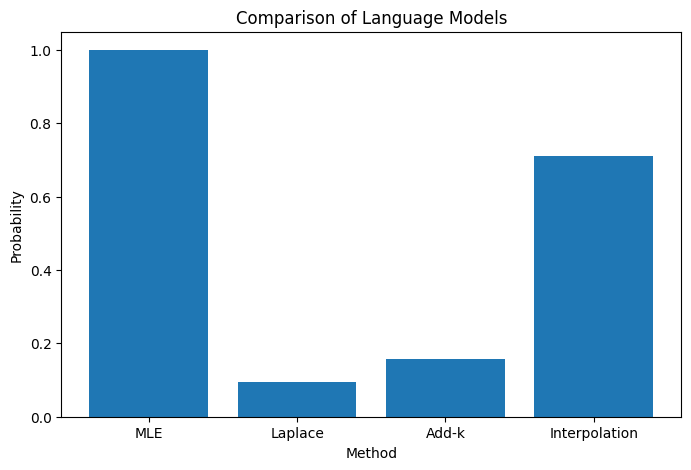

In [20]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Method"],
    comparison["P(intelligence|artificial)"]
)

plt.title("Comparison of Language Models")
plt.xlabel("Method")
plt.ylabel("Probability")

plt.show()